# EDA + Modèle baseline — Détection de fraude

**Bloc 3 RNCP38777 — Pipeline automatisé de détection de fraude**

Ce notebook prépare le modèle ML qui sera servi par MLflow et consommé par le pipeline Kafka.

Étapes :
1. Chargement et exploration du dataset
2. Analyse du déséquilibre (fraude = 0,39 %)
3. Feature engineering reproductible (importé depuis `features.py`)
4. Pipeline scikit-learn unique (réutilisable en production)
5. Entraînement RandomForest baseline avec `class_weight='balanced'`
6. Évaluation avec métriques adaptées au déséquilibre (PR-AUC, F1, Recall)
7. Export `model.pkl` pour le consumer Kafka

## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score, classification_report, confusion_matrix,
    f1_score, precision_recall_curve, precision_score, recall_score, roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Feature engineering importe depuis features.py (CRITIQUE pour no-train-serve-skew)
# Le pipeline serialise utilisera ce module, donc le consumer Kafka pourra unpickler.
from features import (
    FraudFeatureBuilder,
    NUMERIC_FEATURES,
    CATEGORICAL_FEATURES,
    RAW_INPUT_COLS,
)

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_STATE = 42

## 2. Chargement du dataset

In [2]:
CSV_PATH = Path('fraudTest.csv')
df = pd.read_csv(CSV_PATH)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

print(f'Shape : {df.shape}')
print(f'Colonnes : {list(df.columns)}')
df.head(3)

Shape : (555719, 22)
Colonnes : ['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0


## 3. EDA — Profil du déséquilibre

C'est la première chose à comprendre : **dans la détection de fraude, le déséquilibre est extrême**. Une accuracy de 99,6 % serait obtenue par un modèle qui prédit toujours "non-fraude". L'accuracy est donc inutilisable, on travaille avec PR-AUC, recall, precision.

Distribution du label :
  is_fraud=0 (legitime) :  553,574 (99.61 %)
  is_fraud=1 (fraude)   :    2,145 (0.39 %)
  Ratio negatives/positives : 258 : 1


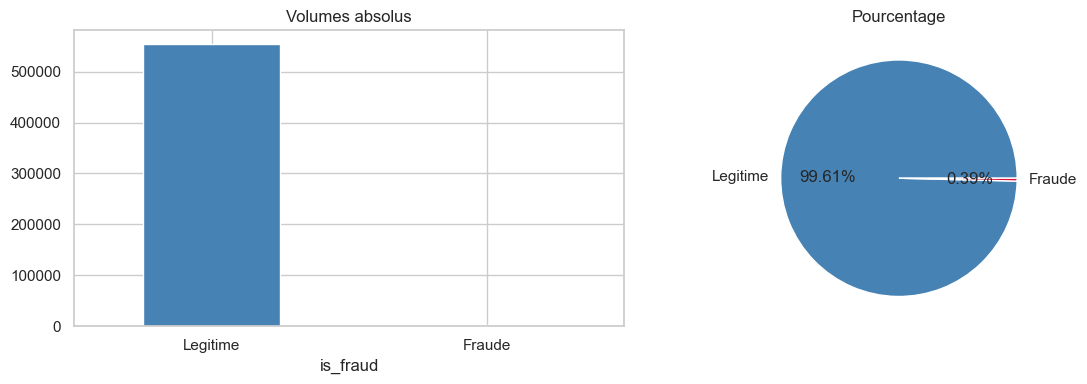

In [3]:
fraud_counts = df['is_fraud'].value_counts()
fraud_pct = fraud_counts / len(df) * 100

print('Distribution du label :')
print(f"  is_fraud=0 (legitime) : {fraud_counts[0]:>8,} ({fraud_pct[0]:.2f} %)")
print(f"  is_fraud=1 (fraude)   : {fraud_counts[1]:>8,} ({fraud_pct[1]:.2f} %)")
print(f"  Ratio negatives/positives : {fraud_counts[0] / fraud_counts[1]:.0f} : 1")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
fraud_counts.plot.bar(ax=ax[0], color=['steelblue', 'crimson'])
ax[0].set_title('Volumes absolus')
ax[0].set_xticklabels(['Legitime', 'Fraude'], rotation=0)
fraud_pct.plot.pie(ax=ax[1], colors=['steelblue', 'crimson'], autopct='%1.2f%%', labels=['Legitime', 'Fraude'])
ax[1].set_title('Pourcentage')
ax[1].set_ylabel('')
plt.tight_layout()
plt.show()

## 4. EDA — Profil des fraudes

On regarde les caractéristiques qui distinguent les fraudes des transactions légitimes.

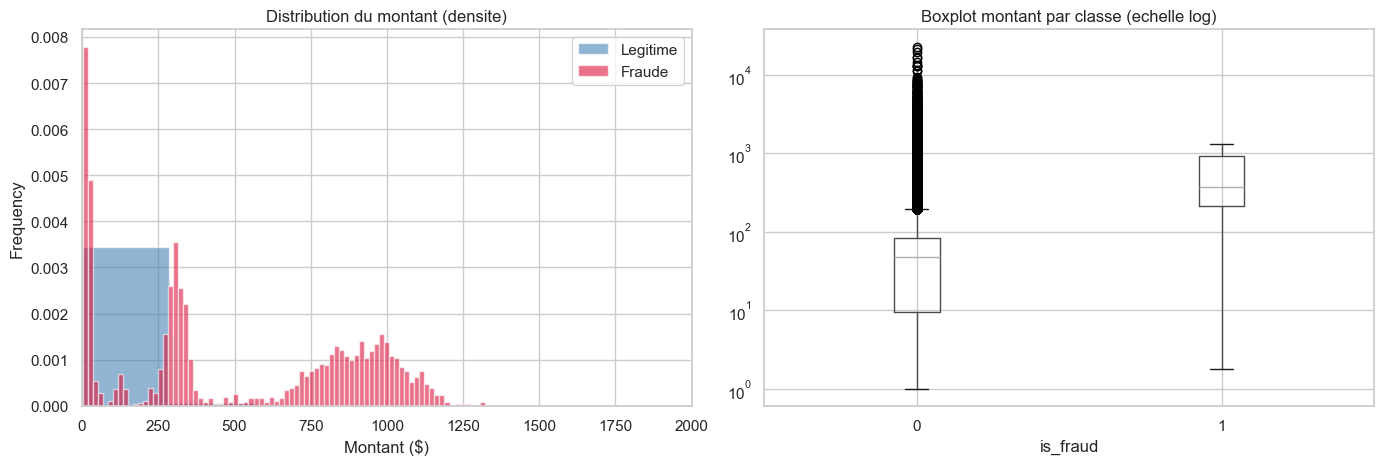

Montant median - legitime : 47.15 $
Montant median - fraude   : 371.94 $


In [4]:
# Distribution du montant
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

df[df['is_fraud'] == 0]['amt'].plot.hist(bins=80, ax=ax[0], alpha=0.6, label='Legitime', color='steelblue', density=True)
df[df['is_fraud'] == 1]['amt'].plot.hist(bins=80, ax=ax[0], alpha=0.6, label='Fraude', color='crimson', density=True)
ax[0].set_xlim(0, 2000)
ax[0].set_xlabel('Montant ($)')
ax[0].set_title('Distribution du montant (densite)')
ax[0].legend()

df.boxplot(column='amt', by='is_fraud', ax=ax[1])
ax[1].set_yscale('log')
ax[1].set_title('Boxplot montant par classe (echelle log)')
ax[1].set_xlabel('is_fraud')
plt.suptitle('')
plt.tight_layout()
plt.show()

print(f"Montant median - legitime : {df[df['is_fraud']==0]['amt'].median():.2f} $")
print(f"Montant median - fraude   : {df[df['is_fraud']==1]['amt'].median():.2f} $")

Taux de fraude par categorie :
                nb_fraudes  nb_total  taux_fraude_pct
category                                             
shopping_net           506     41779             1.21
misc_net               267     27367             0.98
grocery_pos            485     52553             0.92
shopping_pos           213     49791             0.43
gas_transport          154     56370             0.27
travel                  40     17449             0.23
grocery_net             41     19426             0.21
misc_pos                72     34574             0.21
personal_care           70     39327             0.18
entertainment           59     40104             0.15
health_fitness          52     36674             0.14
food_dining             54     39268             0.14
kids_pets               65     48692             0.13
home                    67     52345             0.13


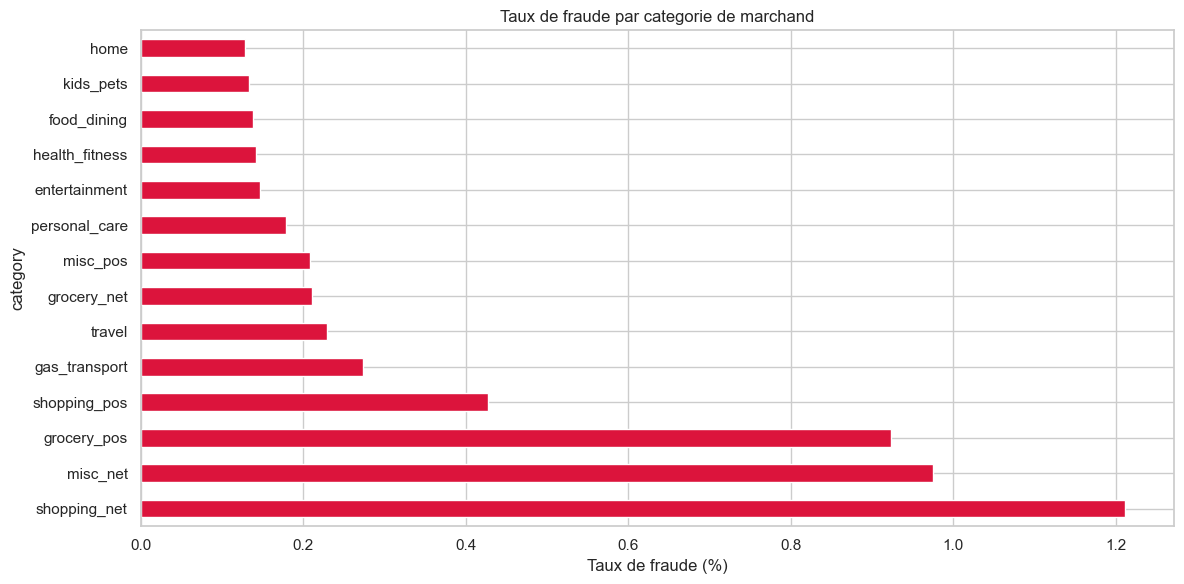

In [5]:
# Top 10 categories de marchands par taux de fraude
fraud_rate_by_cat = df.groupby('category')['is_fraud'].agg(['sum', 'count', 'mean']).sort_values('mean', ascending=False)
fraud_rate_by_cat.columns = ['nb_fraudes', 'nb_total', 'taux_fraude']
fraud_rate_by_cat['taux_fraude_pct'] = fraud_rate_by_cat['taux_fraude'] * 100
print('Taux de fraude par categorie :')
print(fraud_rate_by_cat[['nb_fraudes', 'nb_total', 'taux_fraude_pct']].round(2))

fig, ax = plt.subplots(figsize=(12, 6))
fraud_rate_by_cat['taux_fraude_pct'].plot.barh(ax=ax, color='crimson')
ax.set_xlabel('Taux de fraude (%)')
ax.set_title('Taux de fraude par categorie de marchand')
plt.tight_layout()
plt.show()

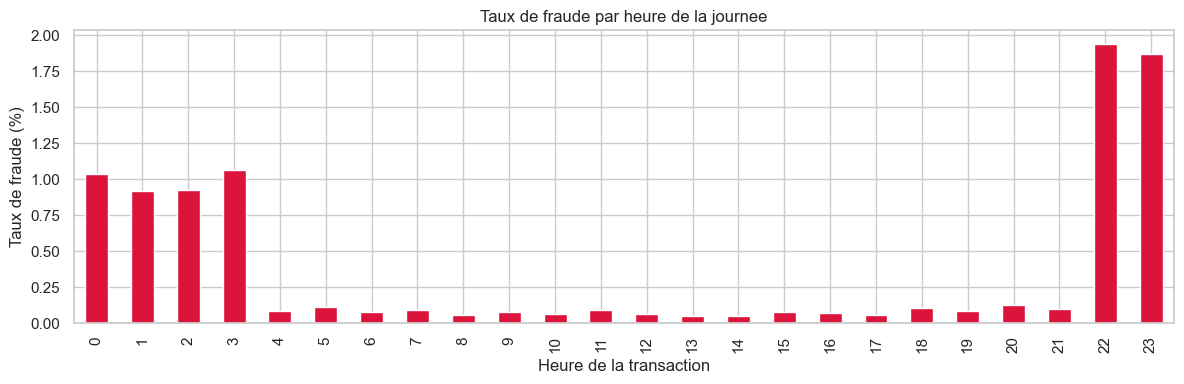

Heure la plus a risque : 22h (1.94 %)
Heure la moins a risque : 14h (0.05 %)


In [6]:
# Distribution temporelle - heure de la journee
df['_hour'] = pd.to_datetime(df['trans_date_trans_time']).dt.hour
fraud_by_hour = df.groupby('_hour')['is_fraud'].mean() * 100

fig, ax = plt.subplots(figsize=(12, 4))
fraud_by_hour.plot.bar(ax=ax, color='crimson')
ax.set_xlabel('Heure de la transaction')
ax.set_ylabel('Taux de fraude (%)')
ax.set_title('Taux de fraude par heure de la journee')
plt.tight_layout()
plt.show()

df = df.drop(columns=['_hour'])
print(f"Heure la plus a risque : {fraud_by_hour.idxmax()}h ({fraud_by_hour.max():.2f} %)")
print(f"Heure la moins a risque : {fraud_by_hour.idxmin()}h ({fraud_by_hour.min():.2f} %)")

**Insights clés :**
- Les fraudes ont des montants **différents** des transactions légitimes (souvent plus élevés ou ciblés)
- Certaines **catégories** sont surreprésentées (`shopping_net`, `grocery_pos`, `misc_net`)
- Les fraudes ont une **forte concentration nocturne** (22h-3h)

→ ces signaux justifient les features qu'on construit dans `features.py` : `amt`, `category`, `hour`, `is_night`.

## 5. Test du feature engineering importé

In [7]:
# Test rapide du transformer importe depuis features.py
fb = FraudFeatureBuilder()
df_sample = fb.transform(df.head(5))
print('Nouvelles features ajoutees par FraudFeatureBuilder :')
df_sample[['hour', 'day_of_week', 'is_weekend', 'is_night', 'age', 'distance_km', 'amt_log']].head()

Nouvelles features ajoutees par FraudFeatureBuilder :


,hour,day_of_week,is_weekend,is_night,age,distance_km,amt_log
0,12,6,1,0,52,24.561462,1.350667
1,12,6,1,0,30,104.925092,3.428813
2,12,6,1,0,49,59.080078,3.744314
3,12,6,1,0,32,27.698567,4.111693
4,12,6,1,0,64,104.335106,1.432701


## 6. Préparation X / y et split stratifié

In [8]:
X = df[RAW_INPUT_COLS].copy()
y = df['is_fraud'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f'Train : {X_train.shape}, fraudes = {y_train.sum()} ({y_train.mean()*100:.2f} %)')
print(f'Test  : {X_test.shape}, fraudes = {y_test.sum()} ({y_test.mean()*100:.2f} %)')

Train : (444575, 12), fraudes = 1716 (0.39 %)
Test  : (111144, 12), fraudes = 429 (0.39 %)


## 7. Pipeline scikit-learn complet

Un seul `Pipeline` qui contient :
1. Le feature engineering (`FraudFeatureBuilder` depuis `features.py`)
2. Le pré-traitement (StandardScaler pour les num, OneHotEncoder pour les cat)
3. Le modèle (RandomForest avec `class_weight='balanced'`)

Cet objet sera **sérialisé en .pkl** et chargé tel quel par `consumer_predictor.py`.

In [9]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUMERIC_FEATURES),
    ('cat', OneHotEncoder(handle_unknown='ignore', max_categories=50), CATEGORICAL_FEATURES),
], remainder='drop')

pipeline = Pipeline([
    ('feature_builder', FraudFeatureBuilder()),
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=150,
        max_depth=20,
        min_samples_leaf=10,
        class_weight='balanced',
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )),
])

print('Pipeline construite :')
for step, transformer in pipeline.steps:
    print(f'  - {step}: {type(transformer).__name__}')

Pipeline construite :
  - feature_builder: FraudFeatureBuilder
  - preprocessor: ColumnTransformer
  - classifier: RandomForestClassifier


## 8. Entraînement

In [10]:
%time pipeline.fit(X_train, y_train)
print('Modele entraine.')

CPU times: total: 14min 16s
Wall time: 53.4 s
Modele entraine.


## 9. Évaluation

Métriques adaptées au déséquilibre :
- **PR-AUC** (Average Precision) : aire sous la courbe précision-rappel
- **Recall@high precision** : combien de fraudes on attrape sans alerter à tort
- **F1-score** sur la classe positive

In [11]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print('=' * 60)
print('METRIQUES SUR LE TEST SET')
print('=' * 60)
print(f'PR-AUC (Average Precision) : {average_precision_score(y_test, y_proba):.4f}')
print(f'ROC-AUC                    : {roc_auc_score(y_test, y_proba):.4f}')
print(f'F1-score                   : {f1_score(y_test, y_pred):.4f}')
print(f'Precision                  : {precision_score(y_test, y_pred):.4f}')
print(f'Recall                     : {recall_score(y_test, y_pred):.4f}')
print()
print('Classification report :')
print(classification_report(y_test, y_pred, target_names=['Legitime', 'Fraude']))

METRIQUES SUR LE TEST SET
PR-AUC (Average Precision) : 0.8331
ROC-AUC                    : 0.9940
F1-score                   : 0.5351
Precision                  : 0.3829
Recall                     : 0.8881

Classification report :
              precision    recall  f1-score   support

    Legitime       1.00      0.99      1.00    110715
      Fraude       0.38      0.89      0.54       429

    accuracy                           0.99    111144
   macro avg       0.69      0.94      0.77    111144
weighted avg       1.00      0.99      1.00    111144



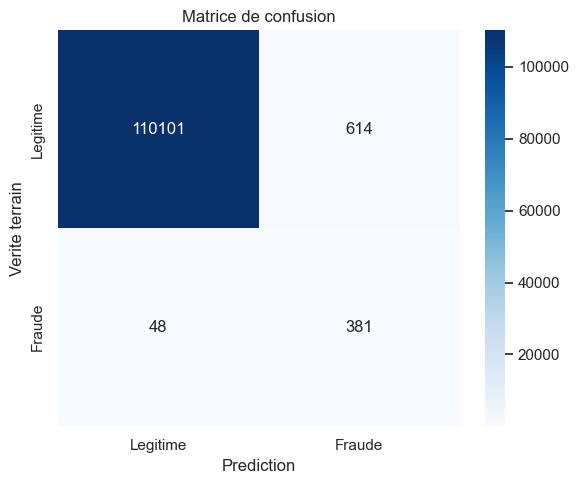

Vrais negatifs   (TN) : 110101
Faux positifs    (FP) :    614  <- alertes a tort
Faux negatifs    (FN) :     48  <- fraudes manquees
Vrais positifs   (TP) :    381  <- fraudes detectees


In [12]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitime', 'Fraude'],
            yticklabels=['Legitime', 'Fraude'], ax=ax)
ax.set_xlabel('Prediction')
ax.set_ylabel('Verite terrain')
ax.set_title('Matrice de confusion')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Vrais negatifs   (TN) : {tn:>6}')
print(f'Faux positifs    (FP) : {fp:>6}  <- alertes a tort')
print(f'Faux negatifs    (FN) : {fn:>6}  <- fraudes manquees')
print(f'Vrais positifs   (TP) : {tp:>6}  <- fraudes detectees')

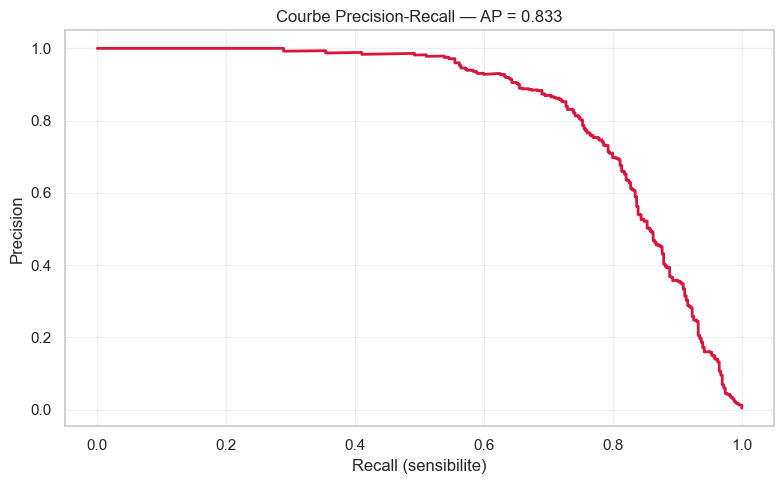

In [13]:
precisions, recalls, _ = precision_recall_curve(y_test, y_proba)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(recalls, precisions, color='crimson', lw=2)
ax.set_xlabel('Recall (sensibilite)')
ax.set_ylabel('Precision')
ax.set_title(f'Courbe Precision-Recall — AP = {average_precision_score(y_test, y_proba):.3f}')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Importance des features

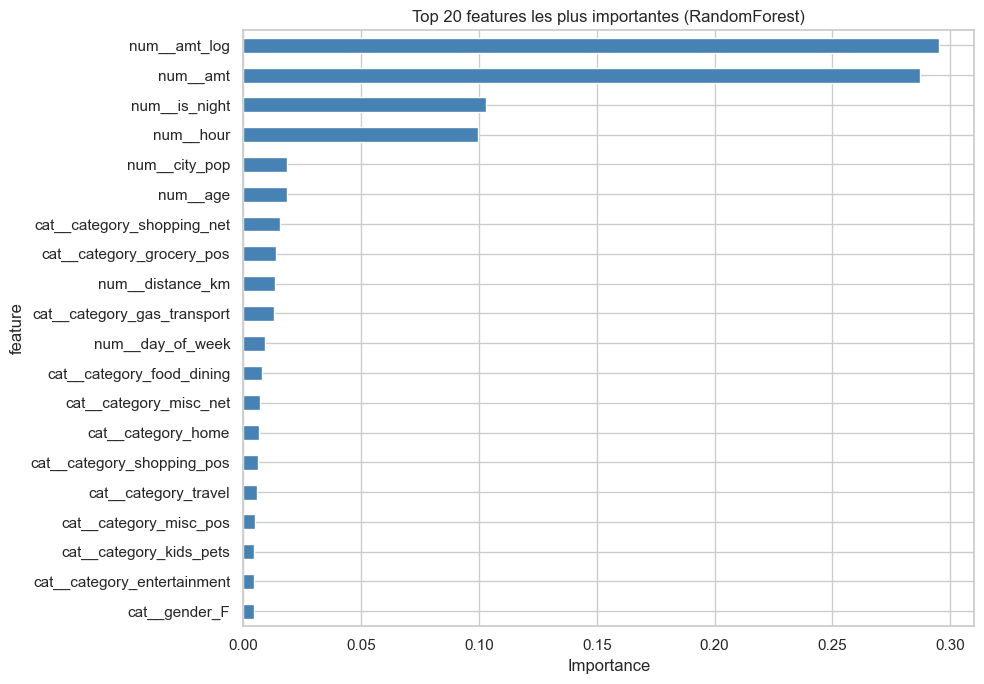

In [14]:
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = pipeline.named_steps['classifier'].feature_importances_

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances,
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
feat_imp.plot.barh(x='feature', y='importance', ax=ax, color='steelblue', legend=False)
ax.invert_yaxis()
ax.set_xlabel('Importance')
ax.set_title('Top 20 features les plus importantes (RandomForest)')
plt.tight_layout()
plt.show()

## 11. Sérialisation du modèle

Le pipeline complet est sauvegardé en un seul fichier. C'est cet artefact qui sera chargé par `consumer_predictor.py`.

In [15]:
MODEL_PATH = Path('model.pkl')
joblib.dump(pipeline, MODEL_PATH)
size_mb = MODEL_PATH.stat().st_size / 1e6
print(f'Modele sauvegarde : {MODEL_PATH} ({size_mb:.1f} Mo)')

# Test de rechargement et prediction sur 1 ligne (simule le pipeline production)
model_loaded = joblib.load(MODEL_PATH)
sample = X_test.head(1)
print(f'\nTest de prediction sur 1 transaction :')
print(f'  Prediction : {model_loaded.predict(sample)[0]}')
print(f'  Score      : {model_loaded.predict_proba(sample)[0, 1]:.4f}')
print('\nLe modele est pret pour le pipeline Kafka.')

Modele sauvegarde : model.pkl (11.1 Mo)

Test de prediction sur 1 transaction :
  Prediction : 0
  Score      : 0.0015

Le modele est pret pour le pipeline Kafka.


## 12. (Optionnel) Logging dans MLflow

In [16]:
try:
    import mlflow
    import mlflow.sklearn

    mlflow.set_tracking_uri('http://localhost:5000')
    mlflow.set_experiment('fraud-detection')

    with mlflow.start_run(run_name='baseline-rf') as run:
        mlflow.log_params({
            'n_estimators': 150,
            'max_depth': 20,
            'min_samples_leaf': 10,
            'class_weight': 'balanced',
        })
        mlflow.log_metrics({
            'pr_auc': average_precision_score(y_test, y_proba),
            'roc_auc': roc_auc_score(y_test, y_proba),
            'f1': f1_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred),
            'recall': recall_score(y_test, y_pred),
        })
        mlflow.sklearn.log_model(
            sk_model=pipeline,
            artifact_path='model',
            registered_model_name='fraud-detector',
        )
        print(f'Run MLflow : {run.info.run_id}')
        print(f'UI : http://localhost:5000')
except Exception as e:
    print(f'MLflow non disponible (ok pour la phase de dev). Detail : {e}')

MLflow non disponible (ok pour la phase de dev). Detail : API request to http://localhost:5000/api/2.0/mlflow/experiments/get-by-name failed with exception HTTPConnectionPool(host='localhost', port=5000): Max retries exceeded with url: /api/2.0/mlflow/experiments/get-by-name?experiment_name=fraud-detection (Caused by NewConnectionError("HTTPConnection(host='localhost', port=5000): Failed to establish a new connection: [WinError 10061] Aucune connexion n’a pu être établie car l’ordinateur cible l’a expressément refusée"))


## Récap

- Modèle baseline entraîné, métriques adaptées au déséquilibre
- `FraudFeatureBuilder` importé depuis `features.py` (no train/serve skew)
- Artefact `model.pkl` prêt à être consommé par `consumer_predictor.py`
- (optionnel) Tracking MLflow pour versioning

**Prochaine étape** : démarrer la stack Kafka avec `docker-compose up` et lancer le producer.